# Hedonic Pricing
We often try to predict the price of an asset from its observable characteristics. This is generally called **hedonic pricing**: How do the unit's characteristics determine its market price?

In the lab folder, there are three options: housing prices in pierce_county_house_sales.csv, car prices in cars_hw.csv, and airbnb rental prices in airbnb_hw.csv. If you know of another suitable dataset, please feel free to use that one.

1. Clean the data and perform some EDA and visualization to get to know the data set.
2. Transform your variables --- particularly categorical ones --- for use in your regression analysis.
3. Implement an ~80/~20 train-test split. Put the test data aside.
4. Build some simple linear models that include no transformations or interactions. Fit them, and determine their RMSE and $R^2$ on the both the training and test sets. Which of your models does the best?
5. Make partial correlation plots for each of the numeric variables in your model. Do you notice any significant non-linearities?
6. Include transformations and interactions of your variables, and build a more complex model that reflects your ideas about how the features of the asset determine its value. Determine its RMSE and $R^2$ on the training and test sets. How does the more complex model your build compare to the simpler ones?
7. Summarize your results from 1 to 6. Have you learned anything about overfitting and underfitting, or model selection?
8. If you have time, use the sklearn.linear_model.Lasso to regularize your model and select the most predictive features. Which does it select? What are the RMSE and $R^2$? We'll cover the Lasso later in detail in class.

In [28]:
# 1. Loading data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.metrics import mean_squared_error, r2_score

import statsmodels.api as sm
from statsmodels.graphics.regressionplots import plot_partregress_grid

df = pd.read_csv("/content/data/pierce_county_house_sales.csv")
df.head()

df.shape

df.info()

df.isnull().sum().sort_values(ascending=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16814 entries, 0 to 16813
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   sale_date                    16814 non-null  object
 1   sale_price                   16814 non-null  int64 
 2   house_square_feet            16814 non-null  int64 
 3   attic_finished_square_feet   16814 non-null  int64 
 4   basement_square_feet         16814 non-null  int64 
 5   attached_garage_square_feet  16814 non-null  int64 
 6   detached_garage_square_feet  16814 non-null  int64 
 7   fireplaces                   16814 non-null  int64 
 8   hvac_description             16807 non-null  object
 9   exterior                     16813 non-null  object
 10  interior                     16807 non-null  object
 11  stories                      16814 non-null  int64 
 12  roof_cover                   16806 non-null  object
 13  year_built                   16

,0
waterfront_type,16261
view_quality,15895
roof_cover,8
hvac_description,7
interior,7
exterior,1
sale_date,0
house_square_feet,0
sale_price,0
detached_garage_square_feet,0


DataFrame shape before handling missing values: (16814, 18)
Missing values per column before handling:


,0


DataFrame shape after handling missing values: (16814, 18)
Missing values per column after handling:


,0


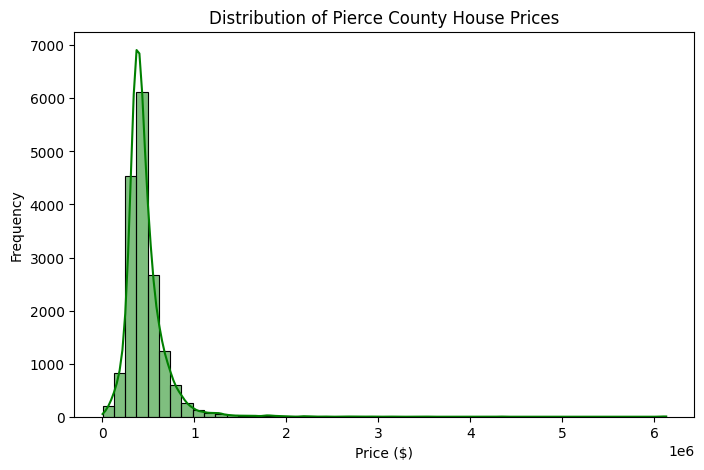

In [42]:
# EDA/cleaning
# Dropping columns that won't help with price analysis (i.e., sale_date)
cols_to_drop = ['sale_date']
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

print(f"DataFrame shape before handling missing values: {df.shape}")
print("Missing values per column before handling:")
display(df.isnull().sum()[df.isnull().sum() > 0])

# Imputing missing values; impute numerical columns with median
for col in ['attic_finished_square_feet', 'basement_square_feet']:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

#Imputing categorical columns with mode
for col in ['hvac_description', 'exterior', 'interior', 'roof_cover', 'waterfront_type', 'view_quality']:
    if col in df.columns and df[col].isnull().any():
        mode_value = df[col].mode()[0] # taking the first value
        df[col] = df[col].fillna(mode_value)

print(f"DataFrame shape after handling missing values: {df.shape}")
print("Missing values per column after handling:")
display(df.isnull().sum()[df.isnull().sum() > 0]) # Should be empty now if all handled

# visualizing distribution of sale_price
import seaborn as sns
plt.figure(figsize=(8, 5))
sns.histplot(df['sale_price'], bins=50, kde=True, color='green')
plt.title('Distribution of Pierce County House Prices')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.show()

### 2. Variable Transformation (Categorical Encoding)

Now, we'll transform our categorical variables using one-hot encoding to prepare them for regression analysis.

In [43]:
# 2. Transforming categorical variables using one-hot encoding
df_processed = pd.get_dummies(df, drop_first=True)

print("DataFrame after one-hot encoding:")
print(df_processed.head())

DataFrame after one-hot encoding:
   sale_price  house_square_feet  attic_finished_square_feet  \
0      380000               2157                           0   
1      383000               2238                           0   
2      419900               1452                           0   
3      251660                832                           0   
4      500000               1780                           0   

   basement_square_feet  attached_garage_square_feet  \
0                     0                          528   
1                     0                          396   
2                     0                            0   
3                     0                            0   
4                   384                          484   

   detached_garage_square_feet  fireplaces  stories  year_built  bedrooms  \
0                            0           0        2        1993         3   
1                            0           0        2        2017         4   
2            

In [44]:
# 3. 80/20 test split
from sklearn.preprocessing import StandardScaler

# Separating features and target
X = df_processed.drop('sale_price', axis=1)
y = df_processed['sale_price']

# 80/20 Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Identify numerical columns for scaling
#need to distinguish between original numerical features and new dummy variables -select non-dummy numerical features before get_dummies
original_numerical_features = df.select_dtypes(include=np.number).columns.tolist()
if 'sale_price' in original_numerical_features:
    original_numerical_features.remove('sale_price')

#filtering X_train.columns to get the ones that correspond to the original numerical features/
actual_numerical_features = [col for col in original_numerical_features if col in X_train.columns]

scaler = StandardScaler()

# Fitting the scaler on the training data's actual numerical features and transform them
X_train[actual_numerical_features] = scaler.fit_transform(X_train[actual_numerical_features])

# Transforming the test data's numerical features using the *fitted* scaler
X_test[actual_numerical_features] = scaler.transform(X_test[actual_numerical_features])

print(f"Training on {X_train.shape[0]} homes.")
print(f"Testing on {X_test.shape[0]} homes.")

Training on 13451 homes.
Testing on 3363 homes.


In [45]:
# 4a. First Simple Linear Model (using all processed features)
# Fitting the model
simple_model = LinearRegression()
simple_model.fit(X_train, y_train)

# Predicting
y_train_pred = simple_model.predict(X_train)
y_test_pred = simple_model.predict(X_test)

# Calculating metrics
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"Simple Model (All Features) Results:")
print(f"Train RMSE: ${train_rmse:,.2f} | Train R^2: {train_r2:.3f}")
print(f"Test RMSE: ${test_rmse:,.2f} | Test R^2: {test_r2:.3f}")

Simple Model (All Features) Results:
Train RMSE: $161,944.67 | Train R^2: 0.507
Test RMSE: $185,767.82 | Test R^2: 0.477


In [46]:
# 4b. second simple linear model
features_for_simple_model_2 = ['house_square_feet', 'year_built']

# Making sure these features exist
X_train_2 = X_train[features_for_simple_model_2]
X_test_2 = X_test[features_for_simple_model_2]

# Initializing and fitting the second simple linear model
simple_model_2 = LinearRegression()
simple_model_2.fit(X_train_2, y_train)

# Predict on training and test sets
y_train_pred_2 = simple_model_2.predict(X_train_2)
y_test_pred_2 = simple_model_2.predict(X_test_2)

# Calculating metrics for the second simple model
train_rmse_2 = np.sqrt(mean_squared_error(y_train, y_train_pred_2))
test_rmse_2 = np.sqrt(mean_squared_error(y_test, y_test_pred_2))

train_r2_2 = r2_score(y_train, y_train_pred_2)
test_r2_2 = r2_score(y_test, y_test_pred_2)

print(f"\nSecond Simple Model Results (Features: {features_for_simple_model_2}):")
print(f"Train RMSE: ${train_rmse_2:,.2f} | Train R^2: {train_r2_2:.3f}")
print(f"Test RMSE: ${test_rmse_2:,.2f} | Test R^2: {test_r2_2:.3f}")


Second Simple Model Results (Features: ['house_square_feet', 'year_built']):
Train RMSE: $194,856.44 | Train R^2: 0.286
Test RMSE: $220,271.09 | Test R^2: 0.265


In [47]:
# 4c. 3rd simple linear model
features_for_simple_model_3 = ['bedrooms', 'bathrooms']

# Making sure these features exist
X_train_3 = X_train[features_for_simple_model_3]
X_test_3 = X_test[features_for_simple_model_3]

# Initializing and fitting the third simple linear model
simple_model_3 = LinearRegression()
simple_model_3.fit(X_train_3, y_train)

# Predict on training and test sets
y_train_pred_3 = simple_model_3.predict(X_train_3)
y_test_pred_3 = simple_model_3.predict(X_test_3)

# Calculating metrics for the third simple model
train_rmse_3 = np.sqrt(mean_squared_error(y_train, y_train_pred_3))
test_rmse_3 = np.sqrt(mean_squared_error(y_test, y_test_pred_3))

train_r2_3 = r2_score(y_train, y_train_pred_3)
test_r2_3 = r2_score(y_test, y_test_pred_3)

print(f"\nThird Simple Model Results (Features: {features_for_simple_model_3}):")
print(f"Train RMSE: ${train_rmse_3:,.2f} | Train R^2: {train_r2_3:.3f}")
print(f"Test RMSE: ${test_rmse_3:,.2f} | Test R^2: {test_r2_3:.3f}")


Third Simple Model Results (Features: ['bedrooms', 'bathrooms']):
Train RMSE: $209,665.39 | Train R^2: 0.173
Test RMSE: $236,237.76 | Test R^2: 0.154


In [48]:
# 4d. 4th simple linear model & comparing all the models
features_for_simple_model_4 = ['stories', 'attached_garage_square_feet']

# Making sure these features exist
X_train_4 = X_train[features_for_simple_model_4]
X_test_4 = X_test[features_for_simple_model_4]

# Initializing and fitting the fourth simple linear model
simple_model_4 = LinearRegression()
simple_model_4.fit(X_train_4, y_train)

# Predict on training and test sets
y_train_pred_4 = simple_model_4.predict(X_train_4)
y_test_pred_4 = simple_model_4.predict(X_test_4)

# Calculating metrics for the fourth simple model
train_rmse_4 = np.sqrt(mean_squared_error(y_train, y_train_pred_4))
test_rmse_4 = np.sqrt(mean_squared_error(y_test, y_test_pred_4))

train_r2_4 = r2_score(y_train, y_train_pred_4)
test_r2_4 = r2_score(y_test, y_test_pred_4)

print(f"\nFourth Simple Model Results (Features: {features_for_simple_model_4}):")
print(f"Train RMSE: ${train_rmse_4:,.2f} | Train R^2: {train_r2_4:.3f}")
print(f"Test RMSE: ${test_rmse_4:,.2f} | Test R^2: {test_r2_4:.3f}")

# --- overall comparison of simple models ---
print("\n--- Overall Comparison of Simple Models ---")
print(f"1. Full Features Model    : Test RMSE: ${train_rmse:,.2f} | Test R^2: {train_r2:.3f}")
print(f"2. house_square_feet, year_built: Test RMSE: ${train_rmse_2:,.2f} | Test R^2: {train_r2_2:.3f}")
print(f"3. bedrooms, bathrooms : Test RMSE: ${train_rmse_3:,.2f} | Test R^2: {train_r2_3:.3f}")
print(f"4. stories, attached_garage_square_feet: Test RMSE: ${train_rmse_4:,.2f} | Test R^2: {train_r2_4:.3f}")

# finding best model based on RMSE/R^2

model_results = [
    ("1. Full Features Model", test_rmse, test_r2),
    ("2. house_square_feet, year_built", test_rmse_2, test_r2_2),
    ("3. bedrooms, bathrooms", test_rmse_3, test_r2_3),
    ("4. stories, attached_garage_square_feet", test_rmse_4, test_r2_4)
]

# Sort by Test RMSE (ascending) and then by Test R^2 (descending) to find the best
best_model_rmse = sorted(model_results, key=lambda x: x[1])[0]
best_model_r2 = sorted(model_results, key=lambda x: x[2], reverse=True)[0]

print(f"\nBased on Test RMSE, the best model is: {best_model_rmse[0]} with RMSE: ${best_model_rmse[1]:,.2f}")
print(f"Based on Test R^2, the best model is: {best_model_r2[0]} with R^2: {best_model_r2[2]:.3f}")


Fourth Simple Model Results (Features: ['stories', 'attached_garage_square_feet']):
Train RMSE: $218,095.89 | Train R^2: 0.105
Test RMSE: $244,763.11 | Test R^2: 0.092

--- Overall Comparison of Simple Models ---
1. Full Features Model    : Test RMSE: $161,944.67 | Test R^2: 0.507
2. house_square_feet, year_built: Test RMSE: $194,856.44 | Test R^2: 0.286
3. bedrooms, bathrooms : Test RMSE: $209,665.39 | Test R^2: 0.173
4. stories, attached_garage_square_feet: Test RMSE: $218,095.89 | Test R^2: 0.105

Based on Test RMSE, the best model is: 1. Full Features Model with RMSE: $185,767.82
Based on Test R^2, the best model is: 1. Full Features Model with R^2: 0.477


Generating partial regression plots for selected numerical features...


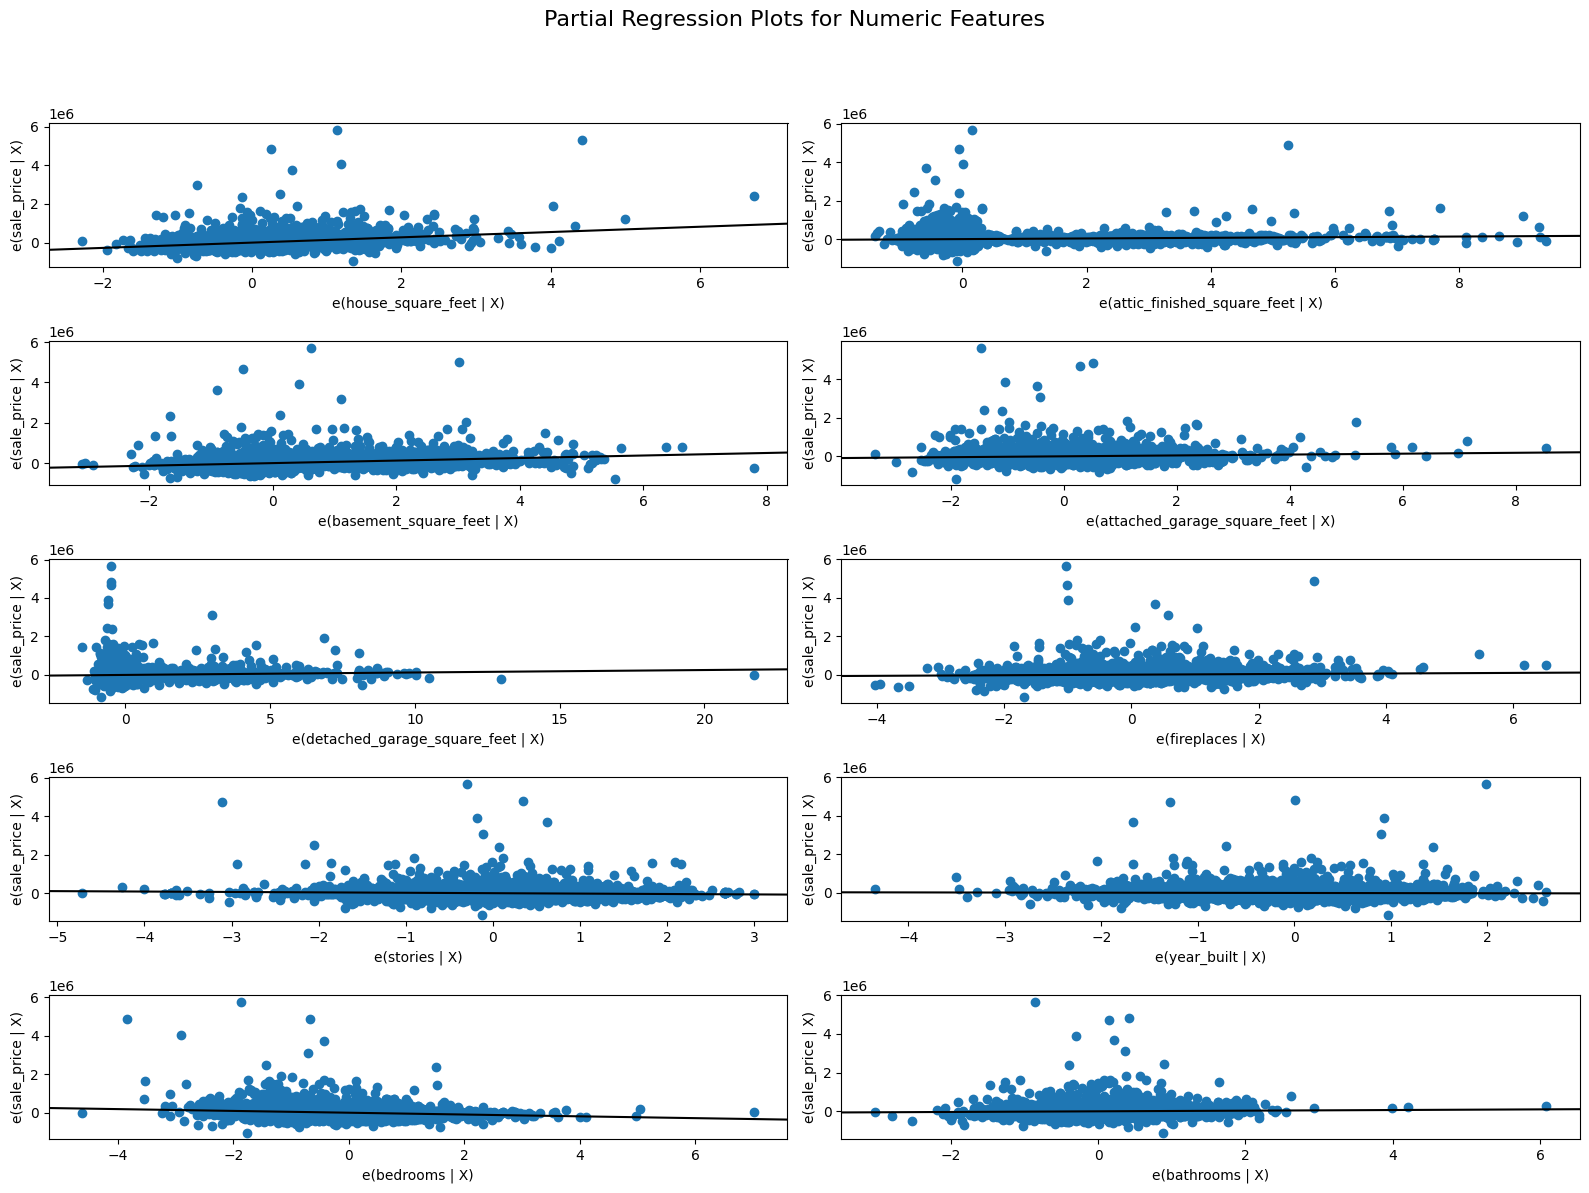

In [49]:
# 5.partial Correlation Plots
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.regressionplots import plot_partregress_grid
import statsmodels.api as sm

# Identifing numerical features from the unscaled dataframe for plotting
# need og values for interpretation in the partial plots, list is used to specify which partial plots to generate
features_to_plot = actual_numerical_features # Defined in step 3

print("Generating partial regression plots for selected numerical features...")

# Creating a figure to hold all subplots
fig = plt.figure(figsize=(16, 12))

# Making sure that X_train only contains numerical types for statsmodels.OLS
X_train_numeric_for_ols = X_train.select_dtypes(include=np.number)

# Adding a constant to the independent variables for statsmodels
X_train_const = sm.add_constant(X_train_numeric_for_ols)

# Fitting the OLS model. statsmodels.OLS handles missing values by default by dropping rows.
model_for_plots = sm.OLS(y_train, X_train_const).fit()

# using plot_partregress_grid with the model and the features to plot
# makign sure 'features_to_plot' are present in the model's exog (X_train_numeric_for_ols)
features_to_plot_in_model = [f for f in features_to_plot if f in X_train_numeric_for_ols.columns]

plot_partregress_grid(model_for_plots, fig=fig, exog_idx=features_to_plot_in_model)
plt.suptitle('Partial Regression Plots for Numeric Features', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent suptitle overlap
plt.show()

To check whether the numeric predictors had roughly linear relationships with sale price, I created partial regression plots for the numeric variables in the model. These plots show the relationship between each variable and sale_price after controlling for the other predictors. Overall, most of the plots look approximately linear, but many show substantial scatter and some extreme outliers. house_square_feet shows the clearest positive relationship with sale price. Variables such as bedrooms, bathrooms, fireplaces, and stories appear more clustered because they are discrete variables. I do not observe severe nonlinearities, but there are mild signs of nonlinearity in some size-related variables, especially house_square_feet. This suggests that the simple linear model is a reasonable starting point, but adding a few nonlinear terms or interactions may improve the more complex model.

In [52]:
# 6. Building a More Complex Model
from sklearn.preprocessing import PolynomialFeatures

# Creating a copy of X_train and X_test to add new features
X_train_complex = X_train.copy()
X_test_complex = X_test.copy()

# Adding squared terms for numerical features that might have non-linear effects (e.g., house_square_feet and year_built
for feature in ['house_square_feet', 'year_built']:
    if feature in X_train_complex.columns:
        X_train_complex[f'{feature}_sq'] = X_train_complex[feature]**2
        X_test_complex[f'{feature}_sq'] = X_test_complex[feature]**2

# Adding Interaction Terms (e.g., interaction between house_square_feet and being on the waterfront)
waterfront_col = [col for col in X_train_complex.columns if 'waterfront_type_WATERFRONT' in col]

if waterfront_col and 'house_square_feet' in X_train_complex.columns:
    X_train_complex['house_sq_ft_x_waterfront'] = X_train_complex['house_square_feet'] * X_train_complex[waterfront_col[0]]
    X_test_complex['house_sq_ft_x_waterfront'] = X_test_complex['house_square_feet'] * X_test_complex[waterfront_col[0]]

# interaction between year_built and house_square_feet
if 'year_built' in X_train_complex.columns and 'house_square_feet' in X_train_complex.columns:
    X_train_complex['house_sq_ft_x_year_built'] = X_train_complex['house_square_feet'] * X_train_complex['year_built']
    X_test_complex['house_sq_ft_x_year_built'] = X_test_complex['house_square_feet'] * X_test_complex['year_built']


# Initializing and fitting the complex linear model
complex_model = LinearRegression()
complex_model.fit(X_train_complex, y_train)

# Predicting on training and test sets
y_train_pred_complex = complex_model.predict(X_train_complex)
y_test_pred_complex = complex_model.predict(X_test_complex)

# Calculating metrics for the complex model
train_rmse_complex = np.sqrt(mean_squared_error(y_train, y_train_pred_complex))
test_rmse_complex = np.sqrt(mean_squared_error(y_test, y_test_pred_complex))

train_r2_complex = r2_score(y_train, y_train_pred_complex)
test_r2_complex = r2_score(y_test, y_test_pred_complex)

print(f"\nComplex Model Results (with transformations and interactions):")
print(f"Train RMSE: ${train_rmse_complex:,.2f} | Train R^2: {train_r2_complex:.3f}")
print(f"Test RMSE: ${test_rmse_complex:,.2f} | Test R^2: {test_r2_complex:.3f}")

print("\n--- Comparison: Complex Model vs. Best Simple Model ---")
print(f"Best Simple Model (Full Features)   : Test RMSE: ${test_rmse:,.2f} | Test R^2: {test_r2:.3f}")
print(f"Complex Model (Transformed + Inter.) : Test RMSE: ${test_rmse_complex:,.2f} | Test R^2: {test_r2_complex:.3f}")


Complex Model Results (with transformations and interactions):
Train RMSE: $160,288.00 | Train R^2: 0.517
Test RMSE: $183,654.63 | Test R^2: 0.489

--- Comparison: Complex Model vs. Best Simple Model ---
Best Simple Model (Full Features)   : Test RMSE: $185,767.82 | Test R^2: 0.477
Complex Model (Transformed + Inter.) : Test RMSE: $183,654.63 | Test R^2: 0.489


For the more complex model, I added squared terms for house_square_feet and year_built to allow for possible nonlinear effects, and I also added interaction terms between house_square_feet and waterfront status and between house_square_feet and year_built. These additions were motivated by the idea that the effect of square footage on sale price may not be constant across all homes, and that size may matter differently for waterfront properties or newer homes.

The complex model performed slightly better than the best simple model. Its test RMSE decreased from $185,767.82 to $183,654.63, and its test R^2 increased from 0.477 to 0.489. This suggests that the added transformations and interactions improved the model’s predictive ability. Since the training and test performance remained fairly close, the complex model does not appear to be severely overfit.

# 7. Summary

In this lab, I used the Pierce County house sales dataset to study how observable housing characteristics affect sale price. I first cleaned the data by checking the variable types and missing values, dropping sale_date from the initial model setup, and handling missing categorical values. I then used one-hot encoding to transform the categorical variables so they could be included in the regression models. After that, I split the data into an 80/20 training and test set so I could compare how well the models fit the training data versus how well they predicted unseen data.

For the simpler models, I tried several different combinations of predictors. The weakest models were the ones using only a small number of variables, such as bedrooms and bathrooms or stories and attached_garage_square_feet. These models had relatively low R^2 values and higher RMSE values, which suggests that they were underfitting the data. They did not include enough information to explain much of the variation in house prices. A model using house_square_feet and year_built did somewhat better, which makes sense because house size and age are more directly related to value.

The best baseline model was the fuller linear model that included all of the processed features without transformations or interactions. This model had a test RMSE of about $185,768 and a test R^2 of 0.477, which was clearly better than the smaller models. This shows that including more relevant housing characteristics improves predictive performance, as long as those variables contain real information about price.

In step 5, I used partial regression plots for the numeric variables to check whether the relationships looked approximately linear. Most of the plots did not show severe nonlinearities, but there were mild signs that some variables, especially house_square_feet, might not affect price in a perfectly linear way. The plots also showed substantial scatter and some outliers, which suggests that a simple linear model may not capture every pattern in the data.

For the more complex model, I added squared terms for house_square_feet and year_built and interaction terms involving house size, waterfront status, and year built. This improved the model slightly: the test RMSE decreased to about $183,655 and the test R^2 increased to 0.489. Since the improvement happened on the test set and not just the training set, this suggests that the added complexity captured some real structure in the data.

Overall, this lab helped me understand the difference between underfitting and overfitting. The smallest models underfit because they were too simple and left out important predictors. The more complete models performed better because they included more relevant information. At the same time, I also saw that adding complexity does not always lead to huge improvements. The complex model only improved a little over the baseline model, which shows that model selection is about finding a balance: the model should be flexible enough to capture important patterns, but not so complicated that it only fits noise in the training data.

I also learned that the test set is very important for model selection. A model may fit the training data well, but what matters most is whether it also performs well on unseen data. In my results, the training and test performance stayed fairly close, especially for the better models, so there was not strong evidence of severe overfitting. This suggests that the final complex model was a reasonable improvement over the simpler models without becoming overly complicated.

In [55]:
# 8. Lasso Regularization & Feature Selection
lasso_model = LassoCV(cv=5, random_state=42, max_iter=10000)

# Fitting the LassoCV model to the complex training data
lasso_model.fit(X_train_complex, y_train)

# Predicting on training and test sets using the best Lasso model
y_train_pred_lasso = lasso_model.predict(X_train_complex)
y_test_pred_lasso = lasso_model.predict(X_test_complex)

# Calculating metrics for the Lasso model
train_rmse_lasso = np.sqrt(mean_squared_error(y_train, y_train_pred_lasso))
test_rmse_lasso = np.sqrt(mean_squared_error(y_test, y_test_pred_lasso))

train_r2_lasso = r2_score(y_train, y_train_pred_lasso)
test_r2_lasso = r2_score(y_test, y_test_pred_lasso)

print(f"\nLasso Model Results (Optimal Alpha: {lasso_model.alpha_:.4f}):")
print(f"Train RMSE: ${train_rmse_lasso:,.2f} | Train R^2: {train_r2_lasso:.3f}")
print(f"Test RMSE: ${test_rmse_lasso:,.2f} | Test R^2: {test_r2_lasso:.3f}")

# Identifying selected features (non-zero coefficients)
selected_features = X_train_complex.columns[lasso_model.coef_ != 0]
print(f"\nNumber of features selected by Lasso: {len(selected_features)}")
print("Selected features:")
for feature in selected_features:
    print(f"- {feature}")

# Comparing Lasso Model to previous models
print("\n--- Comparison: Lasso Model vs. Previous Models ---")
print(f"Best Simple Model (Full Features)   : Test RMSE: ${test_rmse:,.2f} | Test R^2: {test_r2:.3f}")
print(f"Complex Model (Transformed + Inter.) : Test RMSE: ${test_rmse_complex:,.2f} | Test R^2: {test_r2_complex:.3f}")
print(f"Lasso Model (Regularized)            : Test RMSE: ${test_rmse_lasso:,.2f} | Test R^2: {test_r2_lasso:.3f}")


Lasso Model Results (Optimal Alpha: 169.2264):
Train RMSE: $161,310.39 | Train R^2: 0.511
Test RMSE: $184,165.99 | Test R^2: 0.486

Number of features selected by Lasso: 31
Selected features:
- house_square_feet
- attic_finished_square_feet
- basement_square_feet
- attached_garage_square_feet
- detached_garage_square_feet
- fireplaces
- stories
- year_built
- bedrooms
- bathrooms
- hvac_description_Forced Air
- hvac_description_Heat Pump
- hvac_description_No Heat
- hvac_description_Warm and Cool Air Zone
- exterior_Frame Rustic Log
- exterior_Frame Siding
- exterior_Frame Stucco
- exterior_Frame Vinyl
- roof_cover_Composition Shingle
- roof_cover_Concrete Tile
- roof_cover_Formed Seam Metal
- waterfront_type_WF Salt
- view_quality_View Avg +
- view_quality_View Lim
- view_quality_View Lim +
- view_quality_View Lim -
- view_quality_View V-Good
- utility_sewer_SEWER/SEPTIC NO
- house_square_feet_sq
- year_built_sq
- house_sq_ft_x_year_built

--- Comparison: Lasso Model vs. Previous Mod